In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from matplotlib.gridspec import GridSpec

# Defining Global Variable

In [3]:
theta = np.arccos(0.543689)

# 2-Qubit MSD Circuit

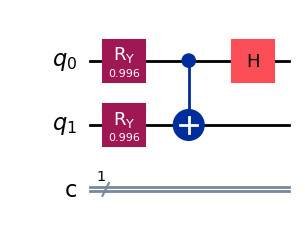

In [4]:
qc = QuantumCircuit(2,1)

# State preparation
qc.ry(theta,0)
qc.ry(theta,1)

# Distillation circuit
qc.cx(0,1)
qc.h(0)

display(qc.draw(output='mpl'))

# Infidelity to Error Rates

In [5]:
def inf_to_error(infidelity_list, num_qubits):
    error_rates_list = []
    dimension = 2**num_qubits
    for infidelity in infidelity_list:
        error_rates_list.append( infidelity * (dimension / (dimension - 1)) )
    
    return error_rates_list

In [6]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [7]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

Consider the case when only state preparation is noisy

In [8]:
ideal = QuantumCircuit(2)
ideal.ry(theta,0)
ideal_dm = DensityMatrix(ideal)

In [9]:
fid_list_noisy_prep = []
shots = 50

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_dm, res_dm['0x0'][0])
    fid_list_noisy_prep.append(temp_fid)

infid_list_noisy_prep = [1-f for f in fid_list_noisy_prep]

Consider the case when every component of the circuit is noisy

In [15]:
fid_list_noisy_all = []
fid_list_noisy_all_unc = []
shots = 100_000

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['h']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(two_qubit_gate_error_prob[i], 2),
        ['cx']
    )
    
    # Add readout errors on the measured qubits.
    readout_err = ReadoutError([
        [1 - spam0[i], spam0[i]],
        [spam1[i], 1 - spam1[i]]
    ])
    noise_model.add_readout_error(readout_err, [0])
    noise_model.add_readout_error(readout_err, [1])
    
    # Measure for post-selection and save the conditional density matrix.
    meas_circuit = qc.copy()
    meas_circuit.measure([1], [0])
    meas_circuit.append(
        SaveDensityMatrix(
            num_qubits=2,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        meas_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(meas_circuit, shots=shots)
    result = job.result()

    # Keep only post-selected shots with measurement outcome 0.
    res_dm = result.data()['dm_post']
    accepted_dm = res_dm['0x0']
    num_meas = len(accepted_dm)
    
    # Average fidelity over accepted shots.
    sumfid = 0
    for shot in accepted_dm:
        sumfid += state_fidelity(shot, ideal_dm)

    sumfid /= num_meas

    fid_list_noisy_all.append(sumfid)

    # 95% normal-approximation uncertainty.
    fid_list_noisy_all_unc.append(
        1.96 * np.sqrt(sumfid * (1 - sumfid) / num_meas)
    )

infid_list_noisy_all = [1-f for f in fid_list_noisy_all]

Input simulations

In [10]:
ideal_input = QuantumCircuit(1)
ideal_input.ry(theta,0)
ideal_input_dm = DensityMatrix(ideal_input)

In [12]:
fid_list_input = []
shots = 1

for i in range(len(one_qubit_gate_error_prob)):
    noise_model = NoiseModel()
    # Add depolarizing noise to state preparation gate. 
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(one_qubit_gate_error_prob[i], 1),
        ['ry']
    )
    
    # Measure for post-selection and save the conditional density matrix.
    input_circuit = QuantumCircuit(1)
    input_circuit.ry(theta,0)
    input_circuit.append(
        SaveDensityMatrix(
            num_qubits=1,
            label='dm_post',
            conditional=True,
            pershot=True
        ),
        input_circuit.qubits
    )
    
    # Run the noisy simulation.
    backend = AerSimulator(noise_model=noise_model, method='density_matrix')
    job = backend.run(input_circuit, shots=shots)
    result = job.result()

    # Keep a post-selected run with measurement outcome 0, and compute its fidelity.
    res_dm = result.data()['dm_post']
    temp_fid = state_fidelity(ideal_input_dm, res_dm[''][0])
    fid_list_input.append(temp_fid)

infid_list_input = [1-f for f in fid_list_input]

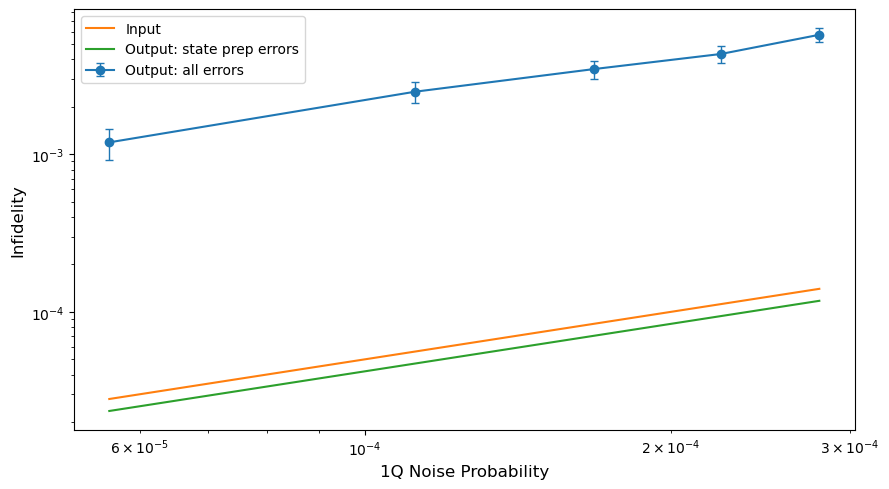

In [16]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    one_qubit_gate_error_prob,
    infid_list_noisy_all,
    yerr=fid_list_noisy_all_unc,
    fmt='o-',           # circle marker and solid line
    capsize=3,          # length of the little “T” caps on each bar
    elinewidth=1,       # width of the error‐bar lines
    markeredgewidth=1,
    label='Output: all errors'
)
plt.plot(one_qubit_gate_error_prob, infid_list_input, label='Input')
plt.plot(one_qubit_gate_error_prob, infid_list_noisy_prep, label='Output: state prep errors')
plt.xlabel("1Q Noise Probability", fontsize=12)
plt.ylabel("Infidelity", fontsize=12)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.show()